In [ ]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb
import src.concept_utils as cu


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl
import scipy.special as sc
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
sys.path.append(os.getcwd())
data

2026-01-20 09:05:08.893242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768896309.021305    8417 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768896309.072710    8417 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def compute_ac_score(correctness_matrix, appearance_matrix):
    na = Na = nc = Nc = 0
    for i in range(len(correctness_matrix)):
        for j in range(len(correctness_matrix[0])):
            if i == j:
                na += correctness_matrix[i][j]
                Na += appearance_matrix[i][j]
            else:
                nc += correctness_matrix[i][j]
                Nc += appearance_matrix[i][j]
    ac_score = (2 * (na/Na) * (nc/Nc))/((na/Na) + (nc/Nc))
    return ac_score

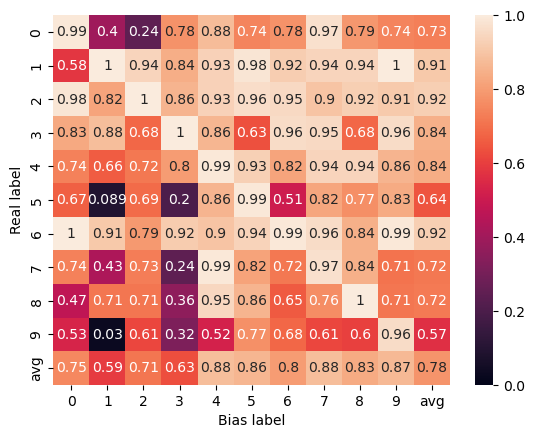

AC score of :  0.86 Accuracy : 78.39


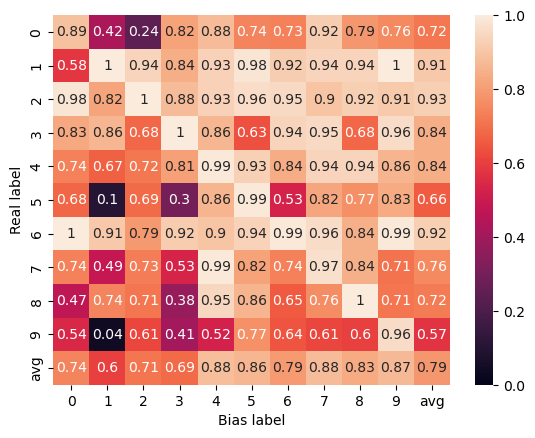

AC score of :  0.86 Accuracy : 78.92


In [ ]:
exp_id = 23
exp_name = "CMNIST"
patch_size_id = 1
concept_id = 1
studied_bias = 0
class_amount = 10
data_folder = ""

with open(f"{data_folder}/models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    model_res = pkl.load(f)
stat = model_res["correctness_matrix"]/model_res["appearance_matrix"]
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=1)).T), axis =1)
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=0))), axis =0)
ax = sb.heatmap(stat, vmin=0, vmax=1, annot=True, xticklabels=list(range(class_amount)) + ["avg"], yticklabels=list(range(class_amount)) + ["avg"])
ax.set(xlabel="Bias label", ylabel="Real label")
plt.show()
plt.show()

print("AC score of : ", round(compute_ac_score(model_res["correctness_matrix"], model_res["appearance_matrix"]),2), "Accuracy :", round(model_res["correctness_matrix"].sum()/model_res["appearance_matrix"].sum()*100, 2))
with open(f"{data_folder}/models/" + exp_name + "/debias_" + str(exp_id) + f"_{concept_id}_{patch_size_id}.pkl", "rb") as f:
    model_res = pkl.load(f)
stat = model_res["correctness_matrix"]/model_res["appearance_matrix"]
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=1)).T), axis =1)
stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=0))), axis =0)
ax = sb.heatmap(stat, vmin=0, vmax=1, annot=True, xticklabels=list(range(class_amount)) + ["avg"], yticklabels=list(range(class_amount)) + ["avg"])
ax.set(xlabel="Bias label", ylabel="Real label")
plt.show()

print("AC score of : ", round(compute_ac_score(model_res["correctness_matrix"], model_res["appearance_matrix"]),2), "Accuracy :", round(model_res["correctness_matrix"].sum()/model_res["appearance_matrix"].sum()*100, 2))

In [ ]:
exp_ids = range(25,30)
exp_name = "CMNIST"
patch_size_id =1
concept_id = 1
res = {"Normal": {"AC-score":[], "Accuracy":[], "Worse acc":[]},
       "Debias": {"AC-score":[], "Accuracy":[], "Worse acc":[]}}
for exp_id in exp_ids:
    with open(f"{data_folder}/models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
        model_res = pkl.load(f)
    stat = model_res["correctness_matrix"]/model_res["appearance_matrix"]
    stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=1)).T), axis =1)
    stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=0))), axis =0)
    res["Normal"]["AC-score"].append(compute_ac_score(model_res["correctness_matrix"], model_res["appearance_matrix"]))
    res["Normal"]["Accuracy"].append(model_res["correctness_matrix"].sum()/model_res["appearance_matrix"].sum())
    res["Normal"]["Worse acc"].append((model_res["correctness_matrix"].sum(axis=1)/model_res["appearance_matrix"].sum(axis=1)).min())

    with open(f"{data_folder}/models/" + exp_name + "/debias_" + str(exp_id) + "_1_1.pkl", "rb") as f:
        model_res = pkl.load(f)
    stat = model_res["correctness_matrix"]/model_res["appearance_matrix"]
    stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=1)).T), axis =1)
    stat = np.concatenate((stat, np.atleast_2d(stat.mean(axis=0))), axis =0)
    res["Debias"]["AC-score"].append(compute_ac_score(model_res["correctness_matrix"], model_res["appearance_matrix"]))
    res["Debias"]["Accuracy"].append(model_res["correctness_matrix"].sum()/model_res["appearance_matrix"].sum())
    res["Debias"]["Worse acc"].append((model_res["correctness_matrix"].sum(axis=1)/model_res["appearance_matrix"].sum(axis=1)).min())

for exp_type in ["Normal", "Debias"]:
    for metric in ["Accuracy", "Worse acc", "AC-score"]:
        arr = np.array(res[exp_type][metric])
        print(f"{round(arr.mean()*100, 1)} $\pm$ {round(100 * arr.std(), 1)}", end=" & ")

95.9 $\pm$ 0.4 & 89.9 $\pm$ 3.2 & 96.0 $\pm$ 0.5 & 95.7 $\pm$ 0.4 & 89.5 $\pm$ 3.1 & 95.5 $\pm$ 0.6 & 

In [ ]:

def get_waterbirds_highest_bias_alignment(exp_name,  exp_id, concept_id, patch_id):
    concept_amounts = [5, 10]
    patch_sizes = [25, 50]
    number_of_concepts = concept_amounts[concept_id]
    with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    res =  []
    for studied_bias in range(2):
        crops_u = concept_res["concept_parameters"][studied_bias]["crops_u"]
        crops = concept_res["concept_parameters"][studied_bias]["crops"]
        masks = concept_res["concept_parameters"][studied_bias]["crop_masks"]
        tmp = 1
        for c_id in range(number_of_concepts):
            best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:100]
            best_masks = masks[best_crops_ids]
            alignment = (((best_masks > 0).mean()))
            if alignment < tmp:
                tmp = alignment
        
        res.append(tmp)
    return res

def get_cmnist_highest_bias_alignment(exp_name,  exp_id, concept_id, patch_id):
    with open(f"{data_folder}/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    res = []
    for studied_bias in range(10):
        W = concept_res["concept_parameters"][studied_bias]["W"]
        tmp = []
        amount = 0
        for label in bias_res[studied_bias]:
            tmp.append(bias_res[studied_bias][label][2])
            amount += len(bias_res[studied_bias][label][2])
        bias_vector = np.concat(tmp, axis=0) / amount
        bias_vector = bias_vector.mean(axis=0)
        alignment = cos_sim([bias_vector], W)[0]
        res.append(alignment.max())
    return res

# res18 = []
# for patch_size_id in range(2):
#     print("Patch size ", patch_size_id)
#     res18.append([])
#     for concept_id in range(2):
#         print("Concept amount ", concept_id)
#         res18[-1].append([])
#         for exp_id in range(0, 5):
#             res18[-1][-1] += get_waterbirds_highest_bias_alignment("Waterbirds18", exp_id, concept_id, patch_size_id)

# res50 = []
# for patch_size_id in range(2):
#     print("Patch size ", patch_size_id)
#     res50.append([])
#     for concept_id in range(2):
#         print("Concept amount ", concept_id)
#         res50[-1].append([])
#         for exp_id in range(0, 5):
#             res50[-1][-1] += get_waterbirds_highest_bias_alignment("Waterbirds50", exp_id, concept_id, patch_size_id)

resbb = []
for patch_size_id in range(3):
    print("Patch size ", patch_size_id)
    resbb.append([])
    for concept_id in range(3):
        print("Concept amount ", concept_id)
        resbb[-1].append([])
        for exp_id in range(20, 25):
            resbb[-1][-1] += get_cmnist_highest_bias_alignment("CMNIST", exp_id, concept_id, patch_size_id)

resuu = []
for patch_size_id in range(3):
    print("Patch size ", patch_size_id)
    resuu.append([])
    for concept_id in range(3):
        print("Concept amount ", concept_id)
        resuu[-1].append([])
        for exp_id in range(25, 30):
            resuu[-1][-1] += get_cmnist_highest_bias_alignment("CMNIST", exp_id, concept_id, patch_size_id)

resbu = []
for patch_size_id in range(3):
    print("Patch size ", patch_size_id)
    resbu.append([])
    for concept_id in range(3):
        print("Concept amount ", concept_id)
        resbu[-1].append([])
        for exp_id in range(30, 35):
            resbu[-1][-1] += get_cmnist_highest_bias_alignment("CMNIST", exp_id, concept_id, patch_size_id)


Patch size  0
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  1
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  2
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  0
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  1
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  2
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  0
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  1
Concept amount  0
Concept amount  1
Concept amount  2
Patch size  2
Concept amount  0
Concept amount  1
Concept amount  2


Text(0.5, 1.0, 'b) Biased model, unbiased validation')

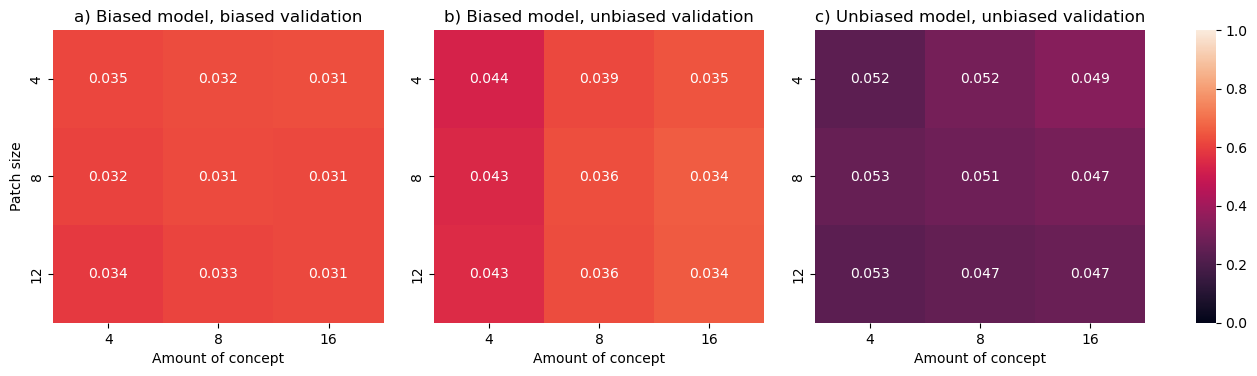

In [18]:
from scipy.stats import sem
fig, axes = plt.subplots(1, 4, figsize=(15,3.8), width_ratios=[0.33, 0.33, 0.33, 0.02])

alignment_resbb = [[sum(el)/len(el) for el in row] for row in resbb]
variance = [[sem(el) for el in row] for row in resbb]
ax = axes[0]
sb.heatmap([[el for el in row] for row in alignment_resbb], ax=ax, vmin=0, vmax=1, annot=variance, xticklabels=[4, 8, 16], yticklabels=[4, 8, 12], cbar=False)
ax.set_xlabel("Amount of concept")
ax.set_ylabel("Patch size")
ax.set_title("a) Biased model, biased validation")

ax=axes[2]
alignment_resuu = [[sum(el)/len(el) for el in row] for row in resuu]
variance = [[sem(el) for el in row] for row in resuu]
sb.heatmap([[el for el in row] for row in alignment_resuu], ax=ax, vmin=0, vmax=1, annot=variance, xticklabels=[4,8, 16], yticklabels=[4, 8, 12], cbar=False)
ax.set_xlabel("Amount of concept")
# ax.set_ylabel("Patch size")
ax.set_title("c) Unbiased model, unbiased validation")

ax=axes[1]
alignment_resbu = [[sum(el)/len(el) for el in row] for row in resbu]
variance = [[sem(el) for el in row] for row in resbu]
sb.heatmap([[el for el in row] for row in alignment_resbu], ax=ax, vmin=0, vmax=1, annot=variance, xticklabels=[4,8, 16], yticklabels=[4, 8, 12], cbar_ax=axes[3])
ax.set_xlabel("Amount of concept")
# ax.set_ylabel("Patch size")
ax.set_title("b) Biased model, unbiased validation")


In [ ]:
def get_waterbirds_concept_relevance(exp_name, exp_id, studied_bias, concept_id, patch_id, verbose=True):
    concept_amounts = [5, 10]
    patch_sizes = [25, 50]
    amount_of_concept = concept_amounts[concept_id]
    with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    relevances = []
    crops_u = concept_res["concept_parameters"][studied_bias]["crops_u"]
    crops = concept_res["concept_parameters"][studied_bias]["crops"]
    masks = concept_res["concept_parameters"][studied_bias]["crop_masks"]
    nb_crops=50
    for c_id in range(amount_of_concept):

        best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
        best_masks = masks[best_crops_ids]
        relevance = ((best_masks > 0).mean())
        if verbose: print("Concept", c_id, ", Relevancy value : ", relevance)
        relevances.append(relevance)
    return relevances

def get_cmnist_bias_alignment(exp_name, studied_bias,  exp_id, concept_id, patch_id, make_fig=True):
    with open(f"{data_folder}/models/{exp_name}/bias_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    W = concept_res["concept_parameters"][studied_bias]["W"]
    big_res = []
    for label in bias_res[studied_bias]:
        truc = bias_res[studied_bias][label][2]
        big_res.append(cos_sim([truc.mean(axis=0)], W)[0])
    big_res.append(sum(big_res)/len(big_res))
    if make_fig:sb.heatmap(big_res, center=0, annot=False, cbar=True, yticklabels=list(range(10)) + ["Avg"])
    return big_res[-1]

def show_freq(exp_name, exp_id, studied_bias, concept_id, patch_id, make_fig = True):
    if exp_name == "CMNIST":
        concept_amounts = [4, 8, 16, 32]
        patch_sizes = [4, 8, 16, 28]
    else:
        concept_amounts = [5, 10]
        patch_sizes = [25, 50]
    amount_of_concept = concept_amounts[concept_id]
    patch_size = patch_sizes[patch_id]
    if make_fig:
        fig, axes = plt.subplots(5, 2, figsize=(50,30))
    steps_amount = [100, 300, 700, 1000] #steps_amount
    fontsize = 32
    with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)

    base_freq = []
    ascent_freq = []
    descent_freq = []
    for step_amount in steps_amount:
        if "false_n" in concept_res["concept_results"][step_amount][studied_bias]:
            results = concept_res["concept_results"][step_amount][studied_bias]["false_n"]
            appearance = len(results["concept_base"])
            base_freq.append(((results["concept_base"] > 0).sum(axis=0))/appearance)
            ascent_freq.append((results["concept_ascent"] > 0).sum(axis=0)/appearance)
            descent_freq.append((results["concept_descent"] > 0).sum(axis=0)/appearance)
        else:
            base_freq.append(np.array([0 for i in range(amount_of_concept)]))
            ascent_freq.append(np.array([0 for i in range(amount_of_concept)]))
            descent_freq.append(np.array([0 for i in range(amount_of_concept)]))
    base_freq = np.stack(base_freq)
    ascent_freq = np.stack(ascent_freq)
    descent_freq = np.stack(descent_freq)
    if make_fig:
        sb.heatmap(ascent_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[0][0])
        axes[0][0].set_title("Ascent frequency", {"fontsize":fontsize})

        sb.heatmap(base_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[1][0])
        axes[1][0].set_title("Base frequency", {"fontsize":fontsize})

        sb.heatmap(descent_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[2][0])
        axes[2][0].set_title("Descent frequency", {"fontsize":fontsize})

    false_n_res = descent_freq - base_freq
    false_n_res[false_n_res < 0] = 0
    if make_fig:
        sb.heatmap(false_n_res, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[3][0])
        axes[3][0].set_title("False negatives results", {"fontsize":fontsize})

    base_freq = []
    ascent_freq = []
    descent_freq = []
    for step_amount in steps_amount:
        if "false_p" in concept_res["concept_results"][step_amount][studied_bias]:
            results = concept_res["concept_results"][step_amount][studied_bias]["false_p"]
            appearance = len(results["concept_base"])
            base_freq.append(((results["concept_base"] > 0).sum(axis=0))/appearance)
            ascent_freq.append((results["concept_ascent"] > 0).sum(axis=0)/appearance)
            descent_freq.append((results["concept_descent"] > 0).sum(axis=0)/appearance)
        else: 
            base_freq.append(np.array([0 for i in range(amount_of_concept)]))
            ascent_freq.append(np.array([0 for i in range(amount_of_concept)]))
            descent_freq.append(np.array([0 for i in range(amount_of_concept)]))
    base_freq = np.stack(base_freq)
    ascent_freq = np.stack(ascent_freq)
    descent_freq = np.stack(descent_freq)
    if make_fig:
        sb.heatmap(ascent_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[0][1])
        axes[0][1].set_title("Ascent frequency", {"fontsize":fontsize})

        sb.heatmap(base_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[1][1])
        axes[1][1].set_title("Base frequency", {"fontsize":fontsize})

        sb.heatmap(descent_freq, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[2][1])
        axes[2][1].set_title("Descent frequency", {"fontsize":fontsize})

    false_p_res = base_freq - descent_freq
    false_p_res[false_p_res < 0] = 0
    if make_fig:
        sb.heatmap(false_p_res, vmin=0, vmax=1, annot=True, yticklabels=steps_amount, ax=axes[3][1])
        axes[3][1].set_title("False negatives results", {"fontsize":fontsize})

    final_res = (false_p_res + false_n_res) /2
    if make_fig:
        sb.heatmap(final_res, center=0, annot=True, yticklabels=steps_amount, ax=axes[4][1])
        axes[4][1].set_title("Final bias estimator", {"fontsize":fontsize})
    return final_res
# get_waterbirds_concept_relevance(exp_name="Waterbirds18", exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id)
# show_freq(exp_name="Waterbirds18", exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id)

In [39]:
import pandas as pd
class_amount=2
def get_max_bias_relevance_res(exp_name="Waterbirds18", exp_range=range(5), concept_id_range=range(1,2), patch_id_range=range(1), step_range=range(4)):
    res = []
    init = False
    for exp_id in exp_range:
        for studied_bias in range(class_amount):
            for concept_id in concept_id_range:
                for patch_size_id in patch_id_range:
                    if exp_name == "CMNIST":
                        relevances = get_cmnist_bias_alignment(exp_name=exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, make_fig = False)
                    else :relevances = 1-np.array(get_waterbirds_concept_relevance(exp_name=exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, verbose = False))
                    bias_res = show_freq(exp_name = exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, make_fig=False)
                    best_bias , bias_val = bias_res.argmax(axis=1), bias_res.max(axis=1)
                    indexes = bias_res.argmax(axis=1)
                    alignment_values = np.array(relevances)[indexes]
                    tmp_res = np.stack([bias_val, alignment_values, np.array(step_range), np.ones_like(bias_val) * studied_bias, np.ones_like(bias_val) * concept_id, np.ones_like(bias_val) * patch_size_id, np.ones_like(bias_val) * exp_id]).T
                    res.append(tmp_res)
    return np.stack(res, axis=0)

def get_second_bias_relevance_res(exp_name="Waterbirds18", exp_range=range(5), concept_id_range=range(1,2), patch_id_range=range(1), step_range=range(4)):
    res = []
    init = False
    for exp_id in exp_range:
        for studied_bias in range(class_amount):
            for concept_id in concept_id_range:
                for patch_size_id in patch_id_range:
                    if exp_name == "CMNIST":
                        relevances = get_cmnist_bias_alignment(exp_name=exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, make_fig = False)
                    else :relevances = 1-get_waterbirds_concept_relevance(exp_name=exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, verbose = False)
                    bias_res = show_freq(exp_name = exp_name, exp_id=exp_id, studied_bias=studied_bias, concept_id=concept_id, patch_id=patch_size_id, make_fig=False)
                    indexes = bias_res.argsort(axis=1)[:,-2]
                    bias_val = np.array([bias_res[i, rank] for i, rank in enumerate(indexes)])
                    alignment_values = np.array(relevances)[indexes]
                    tmp_res = np.stack([bias_val, alignment_values, np.array(step_range), np.ones_like(bias_val) * studied_bias, np.ones_like(bias_val) * concept_id, np.ones_like(bias_val) * patch_size_id, np.ones_like(bias_val) * exp_id]).T
                    res.append(tmp_res)
    return np.stack(res, axis=0)

def make_dataframe(res, is_Waterbirds=False):
    return pd.DataFrame({"Bias estimator":np.concat(res[:,:, 0]), "Bias alignment":(1-np.concat(res[:,:,1]) if is_Waterbirds else np.concat(res[:,:,1])), "Step amount":np.concat(res[:, :, 2]), "Studied bias":np.concat(res[:,:,3]), "Concept id":np.concat(res[:,:,4]), "Patch size id":np.concat(res[:,:,5]), "Exp id":np.concat(res[:,:,6])})

res = get_max_bias_relevance_res(exp_name="Waterbirds18")
data18 = make_dataframe(res, is_Waterbirds=True)
res = get_max_bias_relevance_res(exp_name="Waterbirds50")
data50 = make_dataframe(res, is_Waterbirds=True)
for data in [data18, data50]:
    for step_amount in range(4):
        print(f'For step {step_amount}: {np.corrcoef([data[(data["Step amount"] ==step_amount)]["Bias alignment"], data[(data["Step amount"] ==step_amount)]["Bias estimator"]])[0][1]}')

For step 0: -0.7428626766725059
For step 1: -0.7073010854821502
For step 2: -0.7427131184918921
For step 3: -0.8696147134539718
For step 0: 0.18919208141275426
For step 1: -0.12690826739323494
For step 2: -0.12501241916886152
For step 3: -0.12501241916886152


In [22]:
res = get_max_bias_relevance_res(exp_name="CMNIST", exp_range=range(20, 25), concept_id_range=range(1,2), patch_id_range=range(1,2))
databb = make_dataframe(res)
res = get_max_bias_relevance_res(exp_name="CMNIST", exp_range=range(25, 30), concept_id_range=range(1,2), patch_id_range=range(1,2))
datauu = make_dataframe(res)
res = get_max_bias_relevance_res(exp_name="CMNIST", exp_range=range(30, 35), concept_id_range=range(1,2), patch_id_range=range(1,2))
databu = make_dataframe(res)
for data in [databb, databu, datauu]:
    for step_amount in range(4):
        print(f'For step {step_amount}: {np.corrcoef([data[(data["Step amount"] ==step_amount)]["Bias alignment"], data[(data["Step amount"] ==step_amount)]["Bias estimator"]])[0][1]}')

For step 0: 0.20468090918768705
For step 1: 0.14655240824811003
For step 2: 0.30922078260227515
For step 3: 0.2636532017793832
For step 0: 0.33963452604618927
For step 1: 0.39058465553454896
For step 2: 0.4116332756079392
For step 3: 0.38085844115995593
For step 0: -0.1918583310643422
For step 1: -0.14596446167224705
For step 2: -0.11300571161736411
For step 3: -0.058685777106112


Text(0.5, 1.0, 'c) Unbiased model, unbiased dataloader')

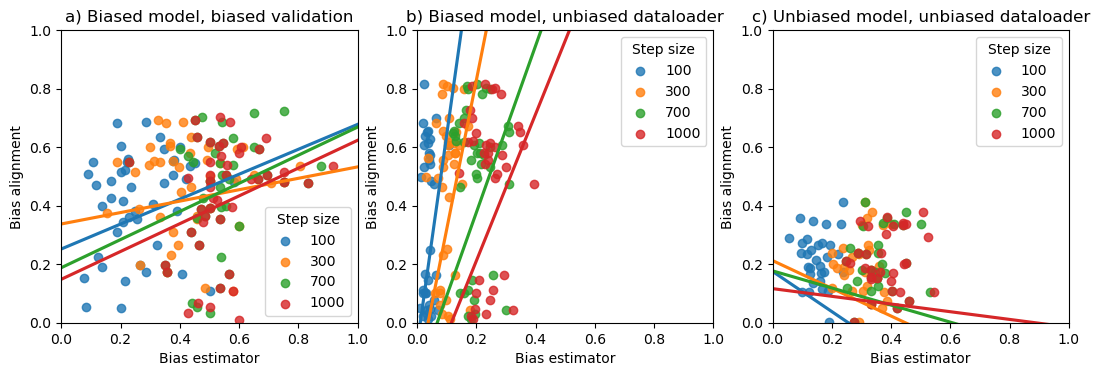

In [25]:
# data = pd.DataFrame({"Bias estimator":np.concat(res[:,:, 0]), "Bias alignment":1 - np.concat(res[:,:,1]), "Step amount":np.concat(res[:, :, 2]), "Studied bias":np.concat(res[:,:,3]), "Concept id":np.concat(res[:,:,4]), "Patch size id":np.concat(res[:,:,5]), "Exp id":np.concat(res[:,:,6])})
fig, axes = plt.subplots(1, 3, figsize=(13,3.8), width_ratios=[0.5, 0.5, 0.5])
# fig, ax = plt.subplots()
# axes=[ax]
data = databb
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
# sb.regplot(data, x="Bias value", y="Bias alignment", scatter=False, label="100", ax=axes[0], ci=100, truncate=False)
a = sb.regplot(data[(data["Step amount"] == 0)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="100", ax=axes[0], truncate=False)
b = sb.regplot(data[(data["Step amount"] == 1)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="300", ax=axes[0], truncate=False)
c = sb.regplot(data[(data["Step amount"] == 2)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="700", ax=axes[0], truncate=False)
d = sb.regplot(data[(data["Step amount"] == 3)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="1000", ax=axes[0], truncate=False)
axes[0].legend(title="Step size")
axes[0].set_title("a) Biased model, biased validation")

data=databu
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
# sb.regplot(data, x="Bias value", y="Bias alignment", scatter=False, label="100", ax=axes[0], ci=100, truncate=False)
a = sb.regplot(data[(data["Step amount"] == 0)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="100", ax=axes[1], truncate=False)
b = sb.regplot(data[(data["Step amount"] == 1)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="300", ax=axes[1], truncate=False)
c = sb.regplot(data[(data["Step amount"] == 2)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="700", ax=axes[1], truncate=False)
d = sb.regplot(data[(data["Step amount"] == 3)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="1000", ax=axes[1], truncate=False)
axes[1].legend(title="Step size")
axes[1].set_title("b) Biased model, unbiased dataloader")

data=datauu
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
# sb.regplot(data, x="Bias value", y="Bias alignment", scatter=False, label="100", ax=axes[0], ci=100, truncate=False)
a = sb.regplot(data[(data["Step amount"] == 0)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="100", ax=axes[2], truncate=False)
b = sb.regplot(data[(data["Step amount"] == 1)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="300", ax=axes[2], truncate=False)
c = sb.regplot(data[(data["Step amount"] == 2)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="700", ax=axes[2], truncate=False)
d = sb.regplot(data[(data["Step amount"] == 3)], x="Bias estimator", y="Bias alignment", fit_reg=True, scatter=True, ci=False, robust=True, label="1000", ax=axes[2], truncate=False)
axes[2].legend(title="Step size")
axes[2].set_title("c) Unbiased model, unbiased dataloader")


# axes[1].set_xlim(0, 1)
# axes[1].set_ylim(0.4, 1)
# sb.regplot(data[(data["Concept id"] == 0)], x="Bias value", y="Bias alignment", scatter=False, label="5", ax=axes[1], ci=60, truncate=False)
# sb.regplot(data[(data["Concept id"] == 1)], x="Bias value", y="Bias alignment", scatter=False, label="10", ax=axes[1], ci=60, truncate=False)
# axes[1].legend()
# axes[1].set_title("b) According to concept amount")
# axes[2].set_xlim(0, 1)
# axes[2].set_ylim(0.4, 1)
# sb.regplot(data[(data["Patch size id"] == 0)], x="Bias value", y="Bias alignment", scatter=False, label="25", ax=axes[2], ci=60, truncate=False)
# sb.regplot(data[(data["Patch size id"] == 1)], x="Bias value", y="Bias alignment", scatter=False, label="50", ax=axes[2], ci=60, truncate=False)
# axes[2].legend()
# axes[2].set_title("a) According to patch size")

In [35]:
for step_amount in range(4):
    print(databu[databu["Step amount"]==step_amount].mean()["Bias alignment"])

0.16651225995272398
0.2823598859831691
0.3370875697210431
0.27789245966821907


Concept 0
Relevancy value :  0.70784


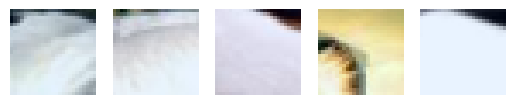

/tmp/ipykernel_87425/1024884549.py:16: RuntimeWarning: invalid value encountered in divide
  img -= img.min();img /= img.max()


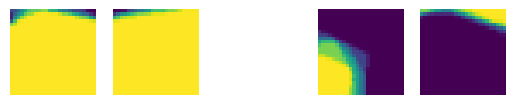




Concept 1
Relevancy value :  0.2


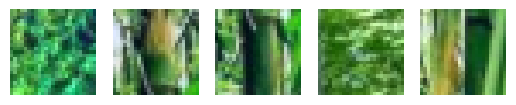

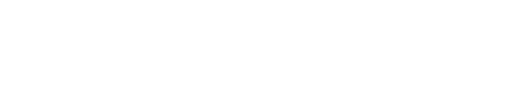




Concept 2
Relevancy value :  0.6


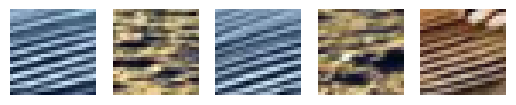

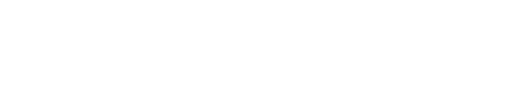




Concept 3
Relevancy value :  0.00704


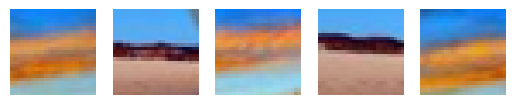

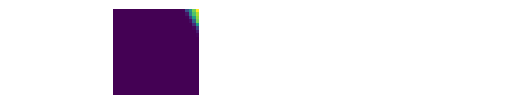




Concept 4
Relevancy value :  0.00256


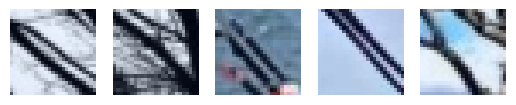

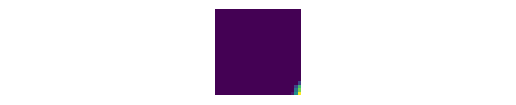




Concept 5
Relevancy value :  0.09472


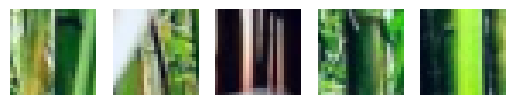

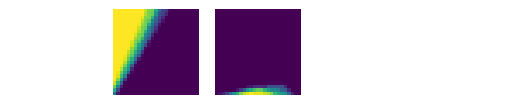




Concept 6
Relevancy value :  0.0


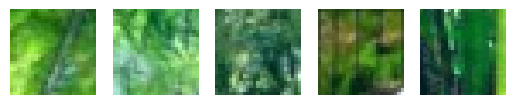

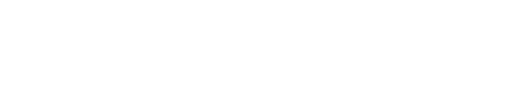




Concept 7
Relevancy value :  0.1504


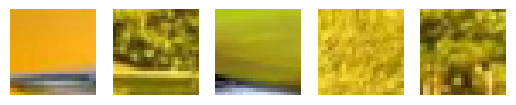

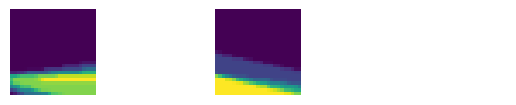




Concept 8
Relevancy value :  0.69344


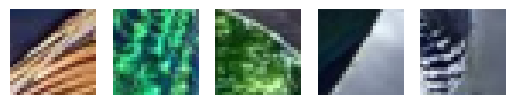

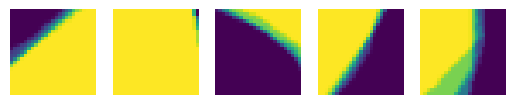




Concept 9
Relevancy value :  0.22752


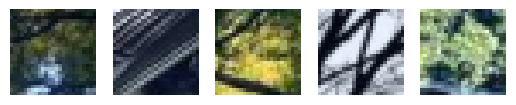

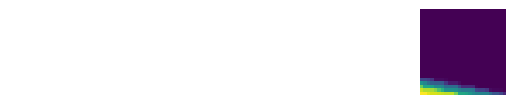

In [ ]:
from math import ceil
exp_name="Waterbirds18"
exp_id=2
concept_id=1
patch_size_id=0
studied_bias=1
concept_amounts = [5, 10]
patch_sizes = [25, 50]
number_of_concepts = concept_amounts[concept_id]

def mask_show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

with open(f"{data_folder}/models/{exp_name}/concepts_{exp_id}_{concept_id}_{patch_size_id}.pkl", "rb") as f:
    concept_res = pkl.load(f)

crops_u = concept_res["concept_parameters"][studied_bias]["crops_u"]
crops = concept_res["concept_parameters"][studied_bias]["crops"]
masks = concept_res["concept_parameters"][studied_bias]["crop_masks"]
nb_crops=5
for c_id in range(number_of_concepts):

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]
  best_masks = masks[best_crops_ids]

  print("Concept", c_id)
  print("Relevancy value : ", (((best_masks > 0).mean())))
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()

  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    mask_show(best_masks[i])
  plt.show()
  print('\n\n')